# 02 — Entrenamiento WGAN-GP

Entrena el generador adversarial sobre `donor_train`. Validación cualitativa con muestras generadas.

Para entrenamiento largo usar el script CLI:

```bash
python scripts/train_wgan_gp.py --seed 42 --epochs 5000
```

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd

from src.data import fit_normalizer, load_donor_windows, windows_to_array
from src.paths import artifacts_dir, default_windows_dir
from src.wgan_gp import TrainConfig, WGAN_GP


I0000 00:00:1788081530.112141  694659 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788081530.112471  694659 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788081530.144929  694659 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788081530.883163  694659 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

In [2]:
SEED = 42
EPOCHS = 300          # subir a 5000+ para producción
BATCH_SIZE = 64
SAMPLE_INTERVAL = 50

train_frame = load_donor_windows("donor_train", windows_dir=default_windows_dir())
train_windows = windows_to_array(train_frame)
normalizer = fit_normalizer(train_windows)

config = TrainConfig(
    seed=SEED,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    sample_interval=SAMPLE_INTERVAL,
)
run_dir = artifacts_dir() / f"seed_{SEED}_notebook"
print(train_windows.shape, run_dir)

(4910, 65, 3) /home/cristian/Documents/miax/modulo5/2026_Modelos_generativos/taller/taller_cristian/generadores/cristian/artifacts/seed_42_notebook


In [3]:
gan = WGAN_GP(config)
generator = gan.train(train_windows, run_dir=run_dir, normalizer=normalizer)

E0000 00:00:1788081531.475951  694659 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1788081531.476221  694733 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1788081531.499240  694659 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


epoch     0 | c_loss=-8.0275 g_loss=10.6552 D(real)=-0.8684 D(fake)=-10.5737
epoch    50 | c_loss=-3.8065 g_loss=10.8856 D(real)=-6.5152 D(fake)=-10.7786
epoch   100 | c_loss=-3.6637 g_loss=2.1885 D(real)=2.0340 D(fake)=-2.1242
epoch   150 | c_loss=-3.9992 g_loss=1.0338 D(real)=3.6793 D(fake)=-0.9059
epoch   200 | c_loss=-4.3319 g_loss=1.2696 D(real)=3.8347 D(fake)=-1.1659
epoch   250 | c_loss=-4.5771 g_loss=2.1134 D(real)=3.3199 D(fake)=-1.9756
epoch   299 | c_loss=-4.7435 g_loss=2.9439 D(real)=2.6930 D(fake)=-2.8068


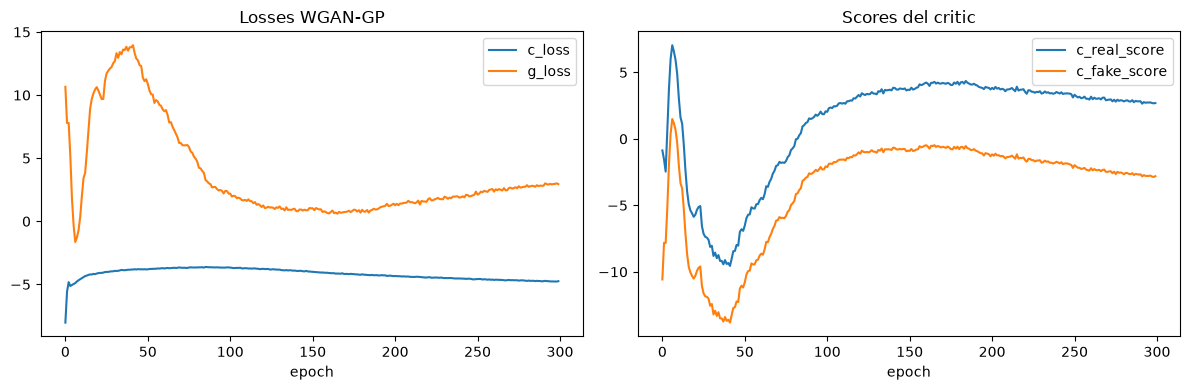

In [4]:
history = pd.read_csv(run_dir / "loss_history.csv")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
history.plot(x="epoch", y=["c_loss", "g_loss"], ax=ax[0])
history.plot(x="epoch", y=["c_real_score", "c_fake_score"], ax=ax[1])
ax[0].set_title("Losses WGAN-GP")
ax[1].set_title("Scores del critic")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "loss_wgan_gp.png", dpi=140, bbox_inches="tight")


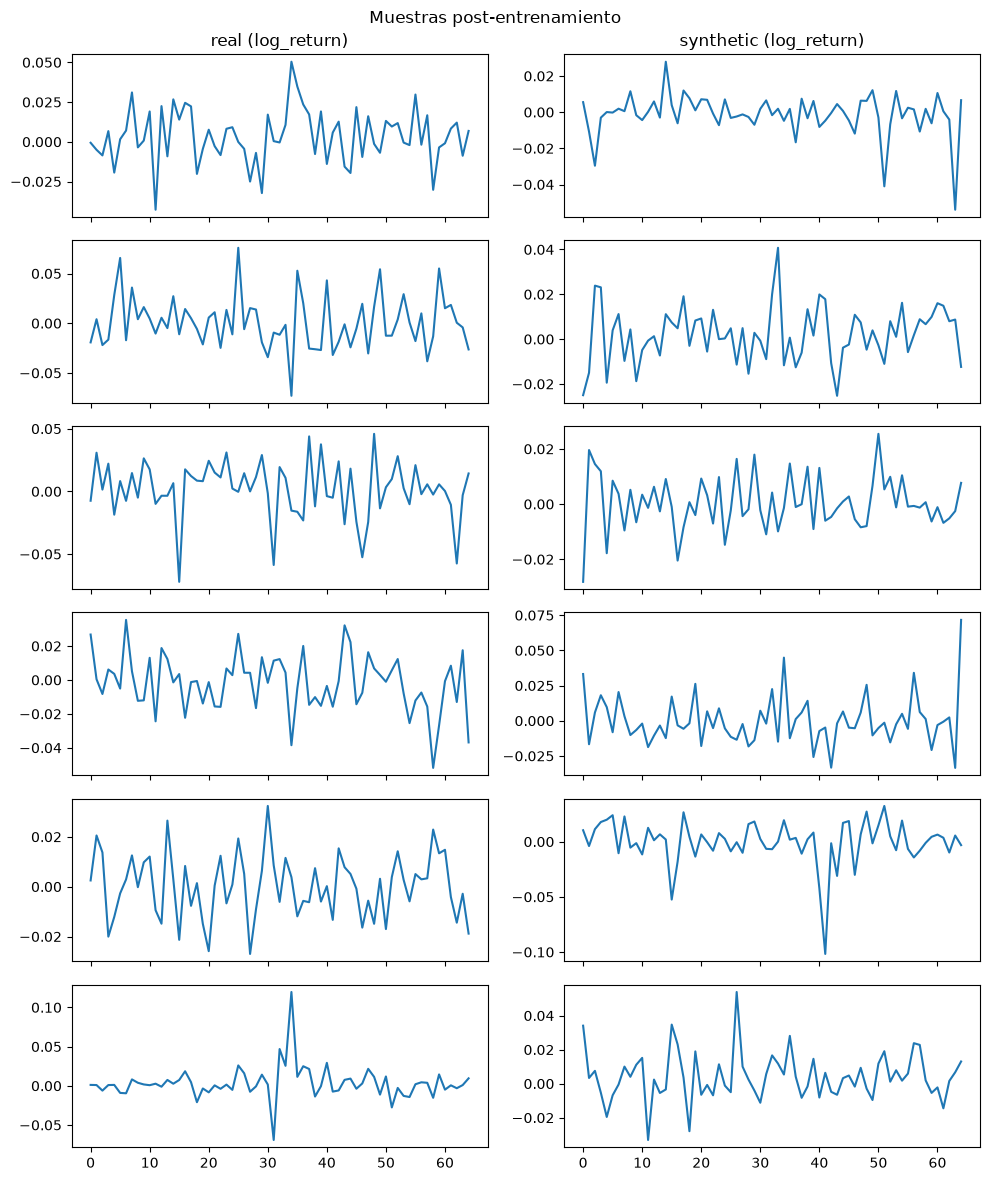

In [5]:
import numpy as np

samples_norm = gan.generate(6, seed=SEED)
samples = normalizer.denormalize(samples_norm)
real = train_windows[np.random.default_rng(SEED).choice(len(train_windows), 6)]

from src.data import CHANNELS

fig, axes = plt.subplots(6, 2, figsize=(10, 12), sharex=True)
for i in range(6):
    axes[i, 0].plot(real[i, :, 0])
    axes[i, 1].plot(samples[i, :, 0])
    if i == 0:
        axes[i, 0].set_title("real (log_return)")
        axes[i, 1].set_title("synthetic (log_return)")
plt.suptitle("Muestras post-entrenamiento")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "muestras_post_entrenamiento.png", dpi=140, bbox_inches="tight")


## Generar ventanas sintéticas (3 seeds × 5000)

Genera por seed:
- `outputs/synthetic_seed{SEED}_n5000_normalized.parquet` — **schema común** (8 columnas como Daniel)
- `outputs/synthetic_seed{SEED}_n5000.parquet` — desnormalizado local (notebooks 03/04)

Requiere checkpoints en `artifacts/seed_42/`, `seed_123/`, `seed_2026/`.

In [ ]:
from src.synthetic_io import (
    generate_synthetic_all_seeds,
    n_synthetic_windows,
    official_seeds,
    synthetic_parquet_path,
    synthetic_parquet_path_normalized,
)

seeds = official_seeds()
n = n_synthetic_windows()
paths = generate_synthetic_all_seeds(seeds=seeds)
print(f"Artefactos generados ({len(seeds)} seeds, parquet + csv):")
for seed in seeds:
    for label, path in [
        ("desnormalizado", synthetic_parquet_path(seed, n)),
        ("normalizado", synthetic_parquet_path_normalized(seed, n)),
    ]:
        print(f"  seed {seed} ({label}): {path.name}, {path.with_suffix('.csv').name}")